In [ ]:
import os
import numpy as np
import warnings
warnings.filterwarnings("ignore")

import random
from random import seed
from PIL import Image
import matplotlib.pyplot as plt
from skimage.io import imread, imshow

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, InputLayer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
!kaggle datasets download -d sahrulsaefuloh/waste-capstone
!unzip waste-capstone.zip -d /content/waste-capstone-dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/waste-capstone-dataset/DATASET/TRAIN/Residu/trash_141_aug_2.jpg  
  inflating: /content/waste-capstone-dataset/DATASET/TRAIN/Residu/trash_141_aug_3.jpg  
  inflating: /content/waste-capstone-dataset/DATASET/TRAIN/Residu/trash_141_aug_4.jpg  
  inflating: /content/waste-capstone-dataset/DATASET/TRAIN/Residu/trash_141_aug_5.jpg  
  inflating: /content/waste-capstone-dataset/DATASET/TRAIN/Residu/trash_141_aug_6.jpg  
  inflating: /content/waste-capstone-dataset/DATASET/TRAIN/Residu/trash_141_aug_7.jpg  
  inflating: /content/waste-capstone-dataset/DATASET/TRAIN/Residu/trash_141_aug_8.jpg  
  inflating: /content/waste-capstone-dataset/DATASET/TRAIN/Residu/trash_141_aug_9.jpg  
  inflating: /content/waste-capstone-dataset/DATASET/TRAIN/Residu/trash_142.jpg  
  inflating: /content/waste-capstone-dataset/DATASET/TRAIN/Residu/trash_142_aug_0.jpg  
  inflating: /content/waste-capstone-dataset/DATASET/TRAIN/Residu/trash_142

In [ ]:
dataset_dir = '/content/waste-capstone-dataset/DATASET'
train_directory = os.path.join(dataset_dir, '/content/waste-capstone-dataset/DATASET/TRAIN')
test_directory = os.path.join(dataset_dir, '/content/waste-capstone-dataset/DATASET/TEST')

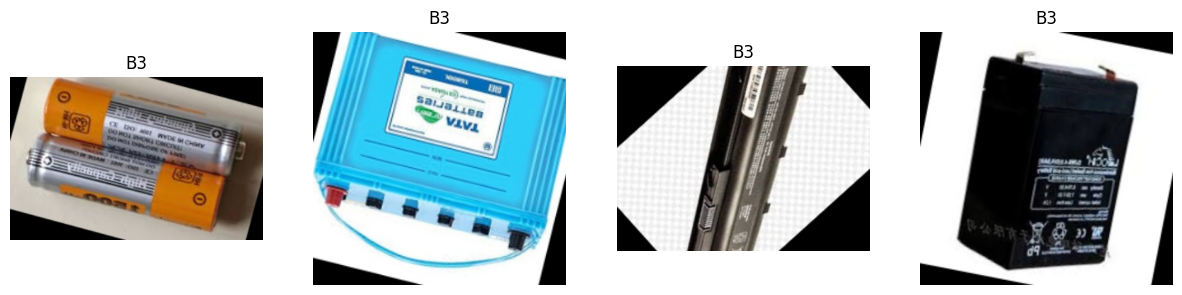

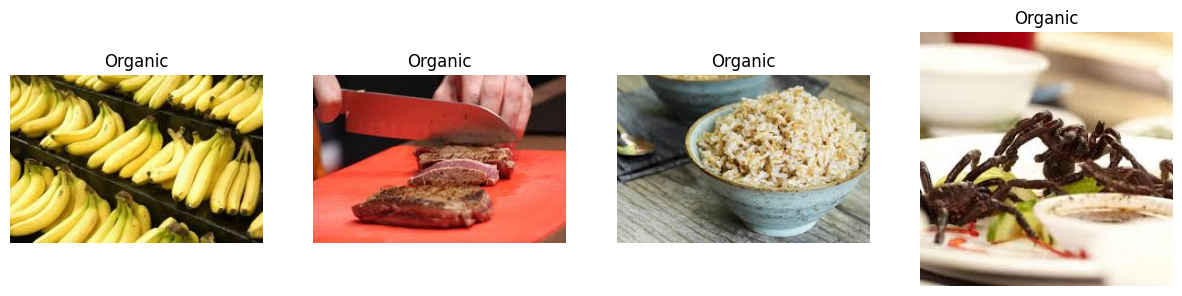

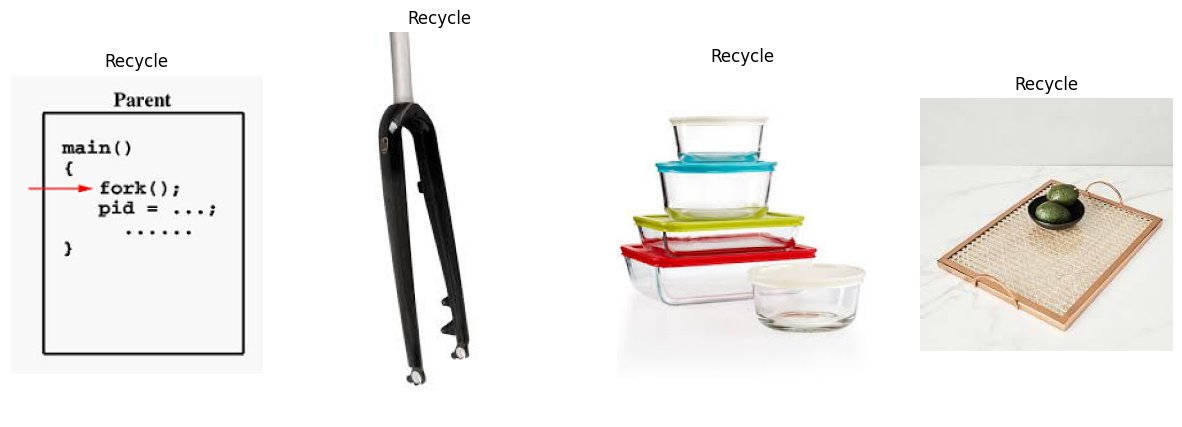

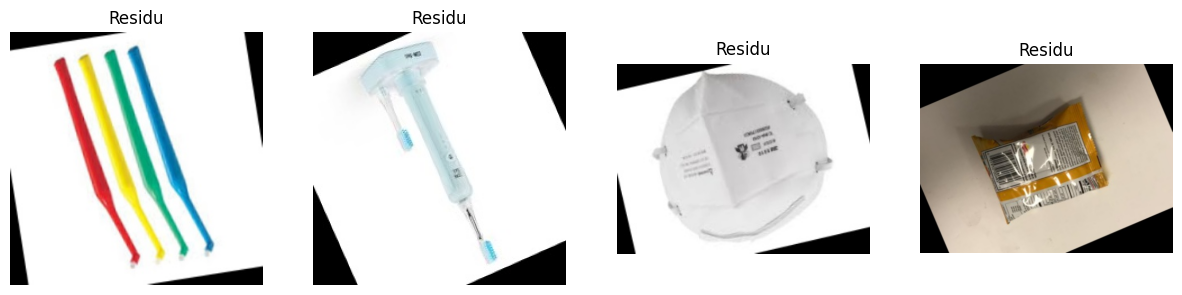

In [ ]:
def plot_random_images(dataset_dir, category, num_images=4):
    category_dir = os.path.join(dataset_dir, category)
    image_files = os.listdir(category_dir)
    random_images = random.sample(image_files, num_images)

    plt.figure(figsize=(15, 5))
    for i, image_name in enumerate(random_images):
        image_path = os.path.join(category_dir, image_name)
        image = Image.open(image_path)
        plt.subplot(1, num_images, i+1)
        plt.imshow(image)
        plt.title(category)
        plt.axis('off')
    plt.show()

categories = ['B3', 'Organic', 'Recycle', 'Residu']
for category in categories:
    plot_random_images(train_directory, category, num_images=4)

In [ ]:
train_data_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2
)

validation_data_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
)

test_data_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [ ]:
train_generator = train_data_generator.flow_from_directory(
    train_directory,
    target_size=(224,224),
    class_mode='categorical',
    batch_size=128,
    shuffle=True,
    subset="training",
    seed=43
)

validation_generator = validation_data_generator.flow_from_directory(
    train_directory,
    target_size=(224,224),
    class_mode='categorical',
    batch_size=128,
    shuffle=True,
    subset="validation",
    seed=43
)

test_generator = test_data_generator.flow_from_directory(
    test_directory,
    target_size=(224,224),
    class_mode='categorical',
    batch_size=128,
    shuffle=False
)

Found 27496 images belonging to 4 classes.
Found 6873 images belonging to 4 classes.
Found 5560 images belonging to 4 classes.


In [ ]:
core = MobileNetV2(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
core.trainable = False

model = Sequential([
    core,
    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(4, activation="softmax")
])

9406464/9406464 [==============================] - 2s 0us/step


In [ ]:
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=["accuracy"])

In [ ]:
earlystopping = EarlyStopping(monitor='val_accuracy', mode='max', patience=5, restore_best_weights=True)
checkpoint_path = "model_checkpoint.keras"
checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_accuracy', mode='max', save_best_only=True, verbose=1)

history = model.fit(train_generator, epochs=15, validation_data=validation_generator, callbacks=[earlystopping, checkpoint])

Epoch 1/15
215/215 [==============================] - ETA: 0s - loss: 1.0785 - accuracy: 0.8302
Epoch 1: val_accuracy improved from -inf to 0.91023, saving model to model_checkpoint.keras
215/215 [==============================] - 388s 2s/step - loss: 1.0785 - accuracy: 0.8302 - val_loss: 0.2659 - val_accuracy: 0.9102
Epoch 2/15
215/215 [==============================] - ETA: 0s - loss: 0.2881 - accuracy: 0.9019
Epoch 2: val_accuracy improved from 0.91023 to 0.92041, saving model to model_checkpoint.keras
215/215 [==============================] - 372s 2s/step - loss: 0.2881 - accuracy: 0.9019 - val_loss: 0.2340 - val_accuracy: 0.9204
Epoch 3/15
215/215 [==============================] - ETA: 0s - loss: 0.2531 - accuracy: 0.9131
Epoch 3: val_accuracy did not improve from 0.92041
215/215 [==============================] - 372s 2s/step - loss: 0.2531 - accuracy: 0.9131 - val_loss: 0.2485 - val_accuracy: 0.9201
Epoch 4/15
215/215 [==============================] - ETA: 0s - loss: 0.2186 -

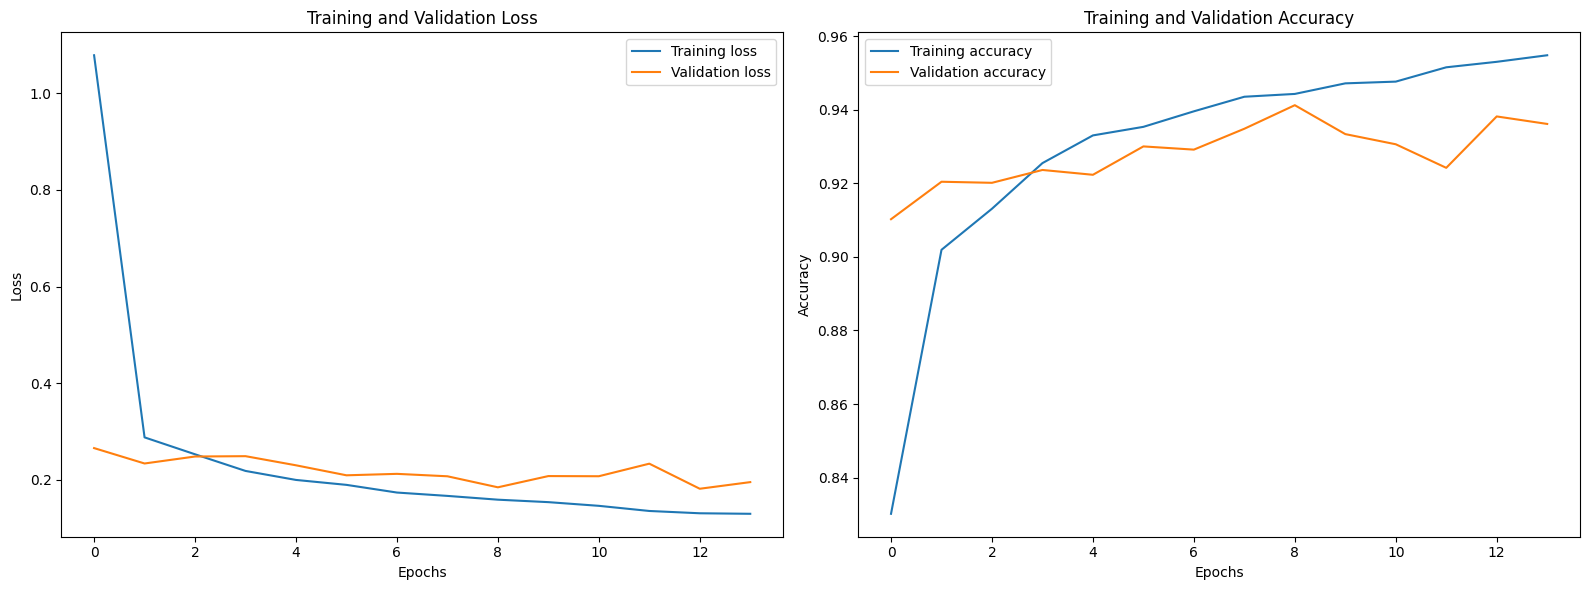

In [ ]:
def plot_training_history(history, metrics=['loss', 'accuracy'], figsize=(12, 5)):
    num_metrics = len(metrics)
    plt.figure(figsize=figsize)
    for i, metric in enumerate(metrics, 1):
        plt.subplot(1, num_metrics, i)
        plt.plot(history.epoch, history.history[metric], label='Training ' + metric)
        plt.plot(history.epoch, history.history['val_' + metric], label='Validation ' + metric)
        plt.title('Training and Validation ' + metric.capitalize())
        plt.xlabel('Epochs')
        plt.ylabel(metric.capitalize())
        plt.legend()
    plt.tight_layout()
    plt.show()

plot_training_history(history, metrics=['loss', 'accuracy'], figsize=(16, 6))

In [ ]:
evaluation = model.evaluate(test_generator)
print(f'Test Loss: {evaluation[0]:.4f}')
print(f'Test Accuracy: {evaluation[1] * 100:.2f}%')

44/44 [==============================] - 15s 344ms/step - loss: 0.2390 - accuracy: 0.9254
Test Loss: 0.2390
Test Accuracy: 92.54%


In [ ]:
test_generator.reset()
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

44/44 [==============================] - 15s 320ms/step


In [ ]:
true_labels = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

class_report = classification_report(true_labels, predicted_classes, target_names=class_labels)
print(class_report)

              precision    recall  f1-score   support

          B3       0.98      0.95      0.96      1595
     Organic       0.91      0.96      0.93      1401
     Recycle       0.84      0.83      0.83      1112
      Residu       0.95      0.95      0.95      1452

    accuracy                           0.93      5560
   macro avg       0.92      0.92      0.92      5560
weighted avg       0.93      0.93      0.93      5560



In [ ]:
conf_matrix = confusion_matrix(true_labels, predicted_classes)
print(conf_matrix)

[[1510    1   66   18]
 [   1 1342   57    1]
 [   8  126  920   58]
 [  20    2   57 1373]]


In [ ]:
from tensorflow import keras

# Load model .keras
model = keras.models.load_model('/content/model_checkpoint.keras')

# Save as .h5
model.save('Recycleme-Model.h5')